<a href="https://colab.research.google.com/github/oscarsanpad/Waveform_optimization_and_design/blob/main/Classiq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!
!python --version
!python -m pip --version

Python 3.13.15
pip 24.1.2 from /usr/local/lib/python3.13/dist-packages/pip (python 3.13)


In [1]:
!pip install -q classiq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 867.6/867.6 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB

In [2]:
import classiq
classiq.authenticate()

/usr/local/lib/python3.13/dist-packages/classiq/__init__.py:110: UserWarning: 'nest_asyncio2' is not installed; falling back to the legacy 'nest_asyncio'. 'nest_asyncio2' ships with modern Jupyter (ipykernel >= 7.3); consider upgrading your Jupyter installation, for example: pip install --upgrade jupyter ipykernel
  enable_jupyter_notebook()


If a browser doesn't automatically open, please visit this URL from any trusted device to authenticate: https://auth.classiq.io/authorize?client_id=f6721qMOVoDAOVkzrv8YaWassRKSFX6Y&response_type=code&audience=https%3A%2F%2Fcadmium-be&redirect_uri=https%3A%2F%2Fauth.classiq.io%2Factivate%3Fuser_code%3DGNKZ-MFGN&scope=offline_access
Your user code: GNKZ-MFGN


NotImplementedError: 

In [ ]:
!pip install pyomo

In [ ]:
import pyomo.environ as pyo

def islr_model(N):
    m = pyo.ConcreteModel()
    m.I = pyo.RangeSet(0, N - 1)                  # índices de chip: 0..N-1
    m.x = pyo.Var(m.I, domain=pyo.Binary)         # 1 bit per chip (Q=2)

    def s(i):                                     # bit -> spin: 0 -> +1, 1 -> -1
        return 1 - 2 * m.x[i]

    def rho(k):                                   # autocorrelación de lag k
        return sum(s(i) * s(i + k) for i in range(N - k))

    m.obj = pyo.Objective(
        expr=sum(rho(k) ** 2 for k in range(1, N)),   # ISLR, lag 0 excluido
        sense=pyo.minimize)
    return m

model = islr_model(7)

In [ ]:
import itertools
for i, b in enumerate((0, 0, 0, 1, 1, 0, 1)):   # Barker-5
    model.x[i].value = b
print(pyo.value(model.obj))               # Must print N-1/2

3


In [ ]:
"""
validar_barker.py -- Validation step from the Thales specifications.

Verifies that the Pyomo ISLR model reproduces the Barker codes from
the brief's reference table for N in {5, 7, 11}, Q = 2 (matched filter case).

Checks three key conditions:
  1. The model's minimum matches the reference value (N-1)/2.
  2. The Barker code from the brief is among the minimizers.
  3. Counts equivalent optima (due to negation and reversal symmetries).
"""

"""
validar_barker.py -- Validation step del enunciado de Thales.

Comprueba que el modelo Pyomo del ISLR reproduce los codigos de Barker
de la tabla del brief para N in {5, 7, 11}, Q = 2 (caso matched).

Verifica tres cosas:
  1. El minimo del modelo coincide con el valor de referencia (N-1)/2.
  2. El codigo de Barker del brief esta entre los minimizadores.
  3. Cuenta los optimos equivalentes (simetrias de negacion y reversion).
"""

import itertools
import pyomo.environ as pyo


# ---------- The model (identical formulation sent to Classiq) ----------
def islr_model(N):
    m = pyo.ConcreteModel()
    m.I = pyo.RangeSet(0, N - 1)                   # chip indices
    m.x = pyo.Var(m.I, domain=pyo.Binary)          # 1 bit per chip (Q = 2)

    def s(i):                                      # bit -> spin mapping: 0 -> +1, 1 -> -1
        return 1 - 2 * m.x[i]

    def rho(k):                                    # Autocorrelation at lag k
        return sum(s(i) * s(i + k) for i in range(N - k))

    m.obj = pyo.Objective(
        expr=sum(rho(k) ** 2 for k in range(1, N)),  # ISLR, excluding lag 0
        sense=pyo.minimize)
    return m


def evaluar(m, bits):
    for i, b in enumerate(bits):
        m.x[i].value = b
    return pyo.value(m.obj)


# ---------- Barker table from specifications (0 -> phase 0, 1 -> phase pi) ----------
BARKER = {
    5:  (0, 0, 0, 1, 0),
    7:  (0, 0, 0, 1, 1, 0, 1),
    11: (0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1),
}


def fases(bits):
    return "-".join("0" if b == 0 else "\u03c0" for b in bits)


def validar(N):
    m = islr_model(N)
    tabla = {b: evaluar(m, b) for b in itertools.product([0, 1], repeat=N)}
    minimo = min(tabla.values())
    optimos = [b for b, v in tabla.items() if v == minimo]

    ref = (N - 1) / 2                     # Reference Barker value from specifications
    barker = BARKER[N]
    valor_barker = tabla[barker]

    print(f"N = {N}   ({2**N} sequences evaluated)")
    print(f"  model minimum ........ {minimo:g}")
    print(f"  reference (N-1)/2 ....... {ref:g}   -> {'OK' if minimo == ref else 'DISCREPANCIA'}")
    print(f"  brief Barker code ......... {fases(barker)}")
    print(f"  its ISLR .................. {valor_barker:g}   -> "
          f"{'OK: it is optimal' if valor_barker == minimo else 'NOT optimal'}")
    print(f"  Equivalent optimals ..... {len(optimos)} (via negation and reversal)")
    print()
    return minimo == ref and valor_barker == minimo


if __name__ == "__main__":
    print("=" * 58)
    print("  VALIDATION STEP -- Pyomo ISLR model vs Barker table")
    print("=" * 58)
    print()
    ok = all(validar(N) for N in (5, 7, 11))
    print("=" * 58)
    print("  RESULT:", "all three cases validated successfully" if ok
          else "mismatches found, please review")
    print("=" * 58)

  VALIDATION STEP -- Pyomo ISLR model vs Barker table

N = 5   (32 sequences evaluated)
  model minimum ........ 2
  reference (N-1)/2 ....... 2   -> OK
  brief Barker code ......... 0-0-0-π-0
  its ISLR .................. 2   -> OK: it is optimal
  Equivalent optimals ..... 4 (via negation and reversal)

N = 7   (128 sequences evaluated)
  model minimum ........ 3
  reference (N-1)/2 ....... 3   -> OK
  brief Barker code ......... 0-0-0-π-π-0-π
  its ISLR .................. 3   -> OK: it is optimal
  Equivalent optimals ..... 4 (via negation and reversal)

N = 11   (2048 sequences evaluated)
  model minimum ........ 5
  reference (N-1)/2 ....... 5   -> OK
  brief Barker code ......... 0-0-0-π-π-π-0-π-π-0-π
  its ISLR .................. 5   -> OK: it is optimal
  Equivalent optimals ..... 4 (via negation and reversal)

  RESULT: all three cases validated successfully


Quantum program link: https://platform.classiq.io/circuit/3JnlBAvubT4BrXGOUCiKXuUv5H2


/usr/local/lib/python3.13/dist-packages/classiq/applications/combinatorial_optimization/combinatorial_problem.py:258: ClassiqDeprecationWarning: ExecutionSession.minimize is deprecated; use variational_minimize instead.
  result = _es.minimize(


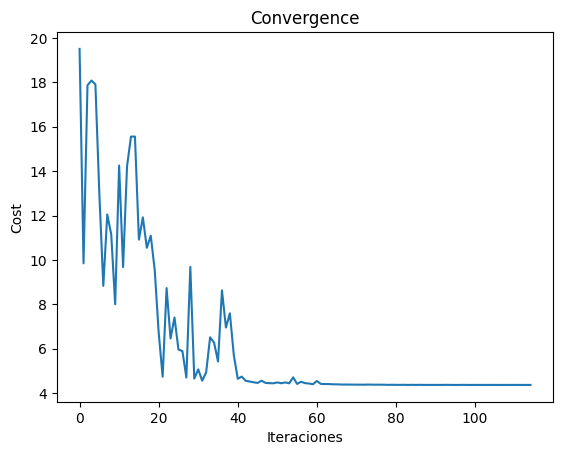

,solution,probability,cost
0,"{'x': [1, 1, 1, 0, 0, 1, 0]}",0.1196,3
1,"{'x': [0, 1, 0, 0, 1, 1, 1]}",0.1183,3
2,"{'x': [1, 0, 1, 1, 0, 0, 0]}",0.1143,3
3,"{'x': [0, 0, 0, 1, 1, 0, 1]}",0.1130,3
4,"{'x': [0, 0, 0, 1, 0, 1, 1]}",0.0259,7
5,"{'x': [1, 0, 1, 1, 1, 1, 0]}",0.0249,7
6,"{'x': [0, 1, 0, 0, 0, 0, 1]}",0.0246,7


In [ ]:
import pyomo.environ as pyo
from classiq import *
import matplotlib.pyplot as plt
from classiq.applications.combinatorial_optimization import CombinatorialProblem
from classiq import ExecutionPreferences, ClassiqBackendPreferences

# 4. Target execution environment: Classiq simulator
execution_preferences = ExecutionPreferences(
    num_shots=10000,
    backend_preferences=ClassiqBackendPreferences(backend_name="simulator"),
)

# 1. Define your optimization problem natively in Pyomo
def islr_model(N):
    m = pyo.ConcreteModel()
    m.I = pyo.RangeSet(0, N - 1)                  # Chip indices: 0..N-1
    m.x = pyo.Var(m.I, domain=pyo.Binary)         # 1 bit per chip (Q=2)

    def s(i):                                     # bit -> spin mapping: 0 -> +1, 1 -> -1
        return 1 - 2 * m.x[i]

    def rho(k):                                   # Autocorrelation at lag k
        return sum(s(i) * s(i + k) for i in range(N - k))

    m.obj = pyo.Objective(
        expr=sum(rho(k) ** 2 for k in range(1, N)),   # ISLR, excluding lag 0
        sense=pyo.minimize)
    return m

model = islr_model(7)

# 2. Pass the Pyomo model directly to Classiq
combi_problem = CombinatorialProblem(
    pyo_model=model,
    num_layers=7,
    penalty_factor=10
)


# 3. Classiq converts it to a quantum model (Qmod) for QAOA
qmod = combi_problem.get_model()
qprog = synthesize(qmod)
show(qprog)


# 5. Hybrid variational loop: quantum evaluates, classical optimizes gamma and beta
optimized_params = combi_problem.optimize(
    execution_preferences, maxiter=150, quantile=0.7
)

# 6. Convergence check: objective cost should decrease over iterations
plt.plot(combi_problem.cost_trace)
plt.xlabel("Iteraciones"); plt.ylabel("Cost"); plt.title("Convergence")
plt.show()

# 7. Sample quantum states using the optimized variational parameters
result = combi_problem.sample(optimized_params)
result.sort_values(by="cost").head(7)



In [ ]:
"""
metricas_qaoa.py -- Performance metrics for a single QAOA run on the ISLR problem.

Usage in notebook, after:
    result = combi_problem.sample(optimized_params)

    metrics(result, N=7, cost_trace=combi_problem.cost_trace)
"""

"""
metricas_qaoa.py -- metricas de desempeno de una corrida QAOA del ISLR.

Uso en el notebook, despues de:
    result = combi_problem.sample(optimized_params)

    metricas(result, N=7, cost_trace=combi_problem.cost_trace)
"""

import itertools


def islr_bits(bits):
    """Exact ISLR of a binary sequence (0 -> phase 0, 1 -> phase pi)."""
    s = [1 - 2 * b for b in bits]
    N = len(s)
    return sum(sum(s[i] * s[i + k] for i in range(N - k)) ** 2
               for k in range(1, N))


def referencia_azar(N):
    """(Optimal ISLR, count of optimal sequences, random probability). Restricted to N <= ~20."""
    vals = [islr_bits(b) for b in itertools.product([0, 1], repeat=N)]
    minimo = min(vals)
    n_opt = vals.count(minimo)
    return minimo, n_opt, n_opt / len(vals)


def metricas(result, N, cost_trace=None):
    """result: DataFrame que devuelve combi_problem.sample()."""
    opt, n_opt, p_azar = referencia_azar(N)

    # Total probability assigned by QAOA to the optimal codes
    p_qaoa = result.loc[result["cost"] == opt, "probability"].sum()
    mejor = result["cost"].min()

    print(f"N = {N}")
    print(f"  optimal ISLR (reference (N-1)/2) .. {opt}")
    print(f"  optimal codes/sequences ................... {n_opt} de {2**N}")
    print(f"  best sampled cost ............ {mejor}"
          f"   -> {'optimal found' if mejor == opt else 'NOT found'}")
    print(f"  P(optimal) random sampling ................. {p_azar:.3%}")
    print(f"  P(optimal) with QAOA ................ {p_qaoa:.3%}")
    print(f"  AMPLIFICATION ..................... {p_qaoa / p_azar:.1f}x"
          f"   ({'signal detected' if p_qaoa / p_azar > 1.5 else 'no improvement over random'})")
    if cost_trace is not None:
        print(f"  final CVaR (cost trace) ................ {cost_trace[-1]:.2f}")
        print(f"  iterations to convergence ....... {len(cost_trace)}")
    return {"N": N, "p_azar": p_azar, "p_qaoa": p_qaoa,
            "amplification": p_qaoa / p_azar, "best": mejor}


if __name__ == "__main__":
    # Test execution using sample numbers from an N=7, 7-layer run
    import pandas as pd
    demo = pd.DataFrame({
        "probability": [.1168, .1158, .1155, .1151, .0242, .0230, .0228],
        "cost":        [3, 3, 3, 3, 7, 7, 7]})
    metricas(demo, N=7, cost_trace=[14.3, 8.0, 4.3])

N = 7
  optimal ISLR (reference (N-1)/2) .. 3
  optimal codes/sequences ................... 4 de 128
  best sampled cost ............ 3   -> optimal found
  P(optimal) random sampling ................. 3.125%
  P(optimal) with QAOA ................ 46.320%
  AMPLIFICATION ..................... 14.8x   (signal detected)
  final CVaR (cost trace) ................ 4.30
  iterations to convergence ....... 3


We observe that we can optimize the algorithm by eliminating negation symmetries.

For example, in a run for N = 7, we obtained the following 4 optimal sequences:
1. 0, 0, 0, 1, 1, 0, 1 (the exact reference sequence by sheer coincidence)
2. 1, 0, 1, 1, 0, 0, 0
3. 0, 1, 0, 0, 1, 1, 1
4. 1, 1, 1, 0, 0, 1, 0

All of them yield an ISLR cost of 3. Since this is the global minimum matching the reference cost of (N-1)/2 specified in the brief for both the Genetic Algorithm and the Barker sequence, all 4 solutions are optimal.

However, notice the pattern: solution 4 is the bitwise negation (invert) of solution 1, and solution 3 is the negation of solution 2. Therefore, we can eliminate these negations as redundant without losing any unique global optima, as the remaining sequences preserve the exact same ISLR value.

To achieve this, we simply fix the first chip to a constant binary value (e.g., x_0 = 0).

Below are the optimized models and results incorporating this symmetry reduction.

In [ ]:
%%writefile metricas_qaoa.py
"""
metricas_qaoa.py -- metricas de desempeno de corridas QAOA del ISLR.

Soporta el modelo con ruptura de simetria (x[0] fijado a 0), que reduce
el espacio de 2^N a 2^(N-1) sin perder optimos.

Uso tipico:
    m = metricas(result, N=7, romper_simetria=True,
                 cost_trace=combi_problem.cost_trace)

    resumen([m1, m2, m3, m4, m5])     # tras varias corridas
"""

import itertools
import statistics


def islr_bits(bits):
    """ISLR exacto de una secuencia binaria (0 -> fase 0, 1 -> fase pi)."""
    s = [1 - 2 * b for b in bits]
    N = len(s)
    return sum(sum(s[i] * s[i + k] for i in range(N - k)) ** 2
               for k in range(1, N))


def referencia_azar(N, romper_simetria=True):
    """ISLR optimo, cuantas secuencias lo alcanzan y su probabilidad al azar.

    Con romper_simetria=True solo cuenta las secuencias con x[0] = 0, que es
    el espacio que realmente explora el circuito. Valido hasta N ~ 20.
    """
    espacio = [b for b in itertools.product([0, 1], repeat=N)
               if not romper_simetria or b[0] == 0]
    vals = [islr_bits(b) for b in espacio]
    minimo = min(vals)
    n_opt = vals.count(minimo)
    return minimo, n_opt, len(espacio), n_opt / len(espacio)


def metricas(result, N, romper_simetria=True, cost_trace=None,
             segundos=None, capas=None, verbose=True):
    """result: DataFrame que devuelve combi_problem.sample()."""
    opt, n_opt, tam, p_azar = referencia_azar(N, romper_simetria)

    p_qaoa = result.loc[result["cost"] == opt, "probability"].sum()
    mejor = result["cost"].min()
    amp = p_qaoa / p_azar

    if verbose:
        print(f"N = {N}" + (f", capas = {capas}" if capas else "")
              + (", simetria rota" if romper_simetria else ""))
        print(f"  ISLR optimo (referencia (N-1)/2) .. {opt}")
        print(f"  codigos optimos ................... {n_opt} de {tam}")
        print(f"  mejor costo muestreado ............ {mejor}"
              f"   -> {'encontro el optimo' if mejor == opt else 'NO lo encontro'}")
        print(f"  P(optimo) al azar ................. {p_azar:.3%}")
        print(f"  P(optimo) con QAOA ................ {p_qaoa:.3%}")
        print(f"  AMPLIFICACION ..................... {amp:.1f}x"
              f"   ({'hay senal' if amp > 1.5 else 'no mejora al azar'})")
        if cost_trace is not None:
            print(f"  CVaR final (curva) ................ {cost_trace[-1]:.2f}")
            print(f"  iteraciones ....................... {len(cost_trace)}")
        if segundos is not None:
            print(f"  tiempo ............................ {segundos:.0f} s")

    return {"N": N, "capas": capas, "optimo": opt, "mejor": mejor,
            "p_azar": p_azar, "p_qaoa": p_qaoa, "amplificacion": amp,
            "cvar": cost_trace[-1] if cost_trace is not None else None,
            "segundos": segundos, "encontro": mejor == opt}


def resumen(corridas):
    """Agrega varias corridas de la MISMA configuracion: mediana y mejor caso."""
    amps = [c["amplificacion"] for c in corridas]
    pqs = [c["p_qaoa"] for c in corridas]
    exitos = sum(c["encontro"] for c in corridas)
    n = len(corridas)
    N, capas = corridas[0]["N"], corridas[0]["capas"]

    print(f"\n--- Resumen de {n} corridas (N = {N}, capas = {capas}) ---")
    print(f"  tasa de exito (halla el optimo) ... {exitos}/{n}")
    print(f"  P(optimo)  mediana / mejor ........ {statistics.median(pqs):.3%}"
          f" / {max(pqs):.3%}")
    print(f"  amplificacion mediana / mejor ..... {statistics.median(amps):.1f}x"
          f" / {max(amps):.1f}x")
    if n > 1:
        print(f"  dispersion (min-max amplif.) ...... "
              f"{min(amps):.1f}x - {max(amps):.1f}x")
    tiempos = [c["segundos"] for c in corridas if c["segundos"]]
    if tiempos:
        print(f"  tiempo mediano .................... "
              f"{statistics.median(tiempos):.0f} s")
    return {"N": N, "capas": capas, "corridas": n, "exitos": exitos,
            "amp_mediana": statistics.median(amps), "amp_mejor": max(amps),
            "p_mediana": statistics.median(pqs)}


if __name__ == "__main__":
    import pandas as pd
    print("=== Efecto de romper la simetria en la referencia al azar ===")
    for N in (5, 7, 11):
        for rs in (False, True):
            o, n_o, tam, p = referencia_azar(N, rs)
            print(f"  N={N:>2} simetria_rota={str(rs):<5} "
                  f"optimo={o:>2}  {n_o} de {tam:>4}  azar={p:.3%}")
    print()
    demo = pd.DataFrame({"probability": [.23, .23, .02, .02],
                         "cost": [3, 3, 7, 7]})
    m = metricas(demo, N=7, romper_simetria=True, cost_trace=[14.3, 6.0, 4.3],
                 segundos=210, capas=7)
    resumen([m, dict(m, p_qaoa=.31, amplificacion=9.9, segundos=198),
             dict(m, p_qaoa=.12, amplificacion=3.8, segundos=205)])

Overwriting metricas_qaoa.py



===== corrida seed=1 =====


/usr/local/lib/python3.13/dist-packages/classiq/applications/combinatorial_optimization/combinatorial_problem.py:258: ClassiqDeprecationWarning: ExecutionSession.minimize is deprecated; use variational_minimize instead.
  result = _es.minimize(


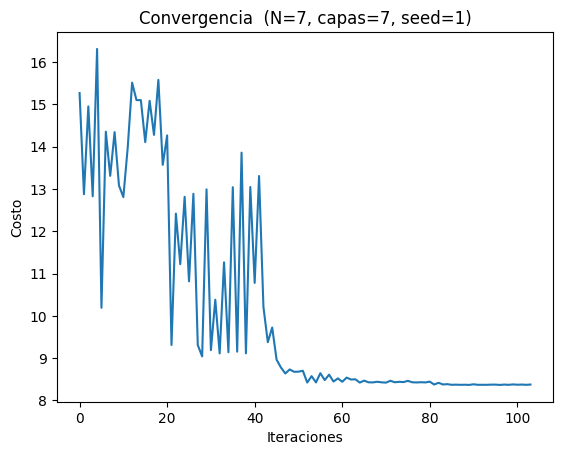

N = 7, capas = 7, simetria rota
  ISLR optimo (referencia (N-1)/2) .. 3
  codigos optimos ................... 2 de 64
  mejor costo muestreado ............ 3   -> encontro el optimo
  P(optimo) al azar ................. 3.125%
  P(optimo) con QAOA ................ 19.250%
  AMPLIFICACION ..................... 6.2x   (hay senal)
  CVaR final (curva) ................ 8.37
  iteraciones ....................... 104
  tiempo ............................ 25 s


,solution,probability,cost
0,"{'x': [0, 0, 0, 1, 1, 0, 1]}",0.1236,3
1,"{'x': [1, 0, 1, 1, 0, 0, 0]}",0.1209,3
2,"{'x': [0, 1, 0, 0, 1, 1, 1]}",0.1203,3
3,"{'x': [1, 1, 1, 0, 0, 1, 0]}",0.1186,3
4,"{'x': [1, 1, 0, 1, 0, 0, 0]}",0.0233,7
5,"{'x': [1, 1, 1, 0, 1, 0, 0]}",0.0233,7
6,"{'x': [1, 0, 1, 1, 1, 1, 0]}",0.0227,7



===== corrida seed=2 =====


/usr/local/lib/python3.13/dist-packages/classiq/applications/combinatorial_optimization/combinatorial_problem.py:258: ClassiqDeprecationWarning: ExecutionSession.minimize is deprecated; use variational_minimize instead.
  result = _es.minimize(


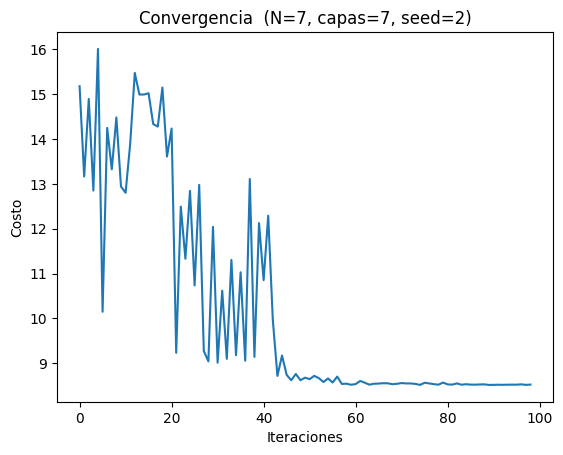

N = 7, capas = 7, simetria rota
  ISLR optimo (referencia (N-1)/2) .. 3
  codigos optimos ................... 2 de 64
  mejor costo muestreado ............ 3   -> encontro el optimo
  P(optimo) al azar ................. 3.125%
  P(optimo) con QAOA ................ 17.480%
  AMPLIFICACION ..................... 5.6x   (hay senal)
  CVaR final (curva) ................ 8.52
  iteraciones ....................... 99
  tiempo ............................ 27 s


,solution,probability,cost
0,"{'x': [0, 0, 0, 1, 1, 0, 1]}",0.1236,3
1,"{'x': [1, 0, 1, 1, 0, 0, 0]}",0.1209,3
2,"{'x': [0, 1, 0, 0, 1, 1, 1]}",0.1203,3
3,"{'x': [1, 1, 1, 0, 0, 1, 0]}",0.1186,3
4,"{'x': [1, 1, 0, 1, 0, 0, 0]}",0.0233,7
5,"{'x': [1, 1, 1, 0, 1, 0, 0]}",0.0233,7
6,"{'x': [1, 0, 1, 1, 1, 1, 0]}",0.0227,7



===== corrida seed=3 =====


/usr/local/lib/python3.13/dist-packages/classiq/applications/combinatorial_optimization/combinatorial_problem.py:258: ClassiqDeprecationWarning: ExecutionSession.minimize is deprecated; use variational_minimize instead.
  result = _es.minimize(


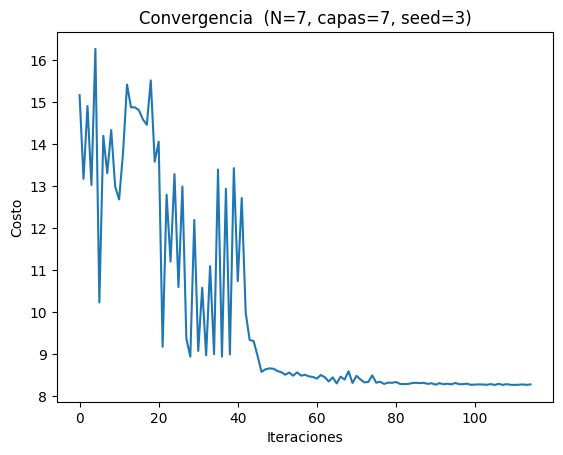

N = 7, capas = 7, simetria rota
  ISLR optimo (referencia (N-1)/2) .. 3
  codigos optimos ................... 2 de 64
  mejor costo muestreado ............ 3   -> encontro el optimo
  P(optimo) al azar ................. 3.125%
  P(optimo) con QAOA ................ 17.250%
  AMPLIFICACION ..................... 5.5x   (hay senal)
  CVaR final (curva) ................ 8.28
  iteraciones ....................... 115
  tiempo ............................ 31 s


,solution,probability,cost
0,"{'x': [0, 0, 0, 1, 1, 0, 1]}",0.1236,3
1,"{'x': [1, 0, 1, 1, 0, 0, 0]}",0.1209,3
2,"{'x': [0, 1, 0, 0, 1, 1, 1]}",0.1203,3
3,"{'x': [1, 1, 1, 0, 0, 1, 0]}",0.1186,3
4,"{'x': [1, 1, 0, 1, 0, 0, 0]}",0.0233,7
5,"{'x': [1, 1, 1, 0, 1, 0, 0]}",0.0233,7
6,"{'x': [1, 0, 1, 1, 1, 1, 0]}",0.0227,7



--- Resumen de 3 corridas (N = 7, capas = 7) ---
  tasa de exito (halla el optimo) ... 3/3
  P(optimo)  mediana / mejor ........ 17.480% / 19.250%
  amplificacion mediana / mejor ..... 5.6x / 6.2x
  dispersion (min-max amplif.) ...... 5.5x - 6.2x
  tiempo mediano .................... 27 s


In [ ]:
# =====================================================================
#  QAOA para diseno de forma de onda (ISLR) -- Classiq
#  Version con ruptura de simetria + multi-arranque
# =====================================================================

import time
import pyomo.environ as pyo
import matplotlib.pyplot as plt
from classiq import *
from classiq.applications.combinatorial_optimization import CombinatorialProblem
from classiq import ExecutionPreferences, ClassiqBackendPreferences

from metricas_qaoa import metricas, resumen    # el modulo de metricas


# ---------------------------------------------------------------------
# 1. El modelo Pyomo
# ---------------------------------------------------------------------
def islr_model(N, romper_simetria=True):
    m = pyo.ConcreteModel()
    inicio = 1 if romper_simetria else 0
    m.I = pyo.RangeSet(inicio, N - 1)          # el chip 0 no es variable
    m.x = pyo.Var(m.I, domain=pyo.Binary)

    def s(i):                                  # chip 0 = constante en fase 0
        return 1 if (romper_simetria and i == 0) else 1 - 2 * m.x[i]

    def rho(k):
        return sum(s(i) * s(i + k) for i in range(N - k))

    m.obj = pyo.Objective(
        expr=sum(rho(k) ** 2 for k in range(1, N)),
        sense=pyo.minimize)
    return m


# ---------------------------------------------------------------------
# 2. Una corrida completa
# ---------------------------------------------------------------------
def corrida(N, capas, seed, num_shots=10000, maxiter=150, quantile=0.7,
            romper_simetria=True, graficar=False):
    """Sintetiza, optimiza, muestrea y devuelve las metricas de una corrida."""
    prefs = ExecutionPreferences(
        num_shots=num_shots,
        random_seed=seed,                          # <-- cambia entre corridas
        backend_preferences=ClassiqBackendPreferences(backend_name="simulator"),
    )

    model = islr_model(N, romper_simetria)
    combi = CombinatorialProblem(pyo_model=model, num_layers=capas)

    t0 = time.time()
    params = combi.optimize(prefs, maxiter=maxiter, quantile=quantile)
    segundos = time.time() - t0

    result = combi.sample(params)

    if graficar:
        plt.plot(combi.cost_trace)
        plt.xlabel("Iteraciones"); plt.ylabel("Costo")
        plt.title(f"Convergencia  (N={N}, capas={capas}, seed={seed})")
        plt.show()

    return metricas(result, N, romper_simetria=romper_simetria,
                    cost_trace=combi.cost_trace, segundos=segundos,
                    capas=capas), result


# ---------------------------------------------------------------------
# 3. Multi-arranque: varias semillas, misma configuracion
# ---------------------------------------------------------------------
def multi_arranque(N, capas, semillas=(1, 2, 3), mostrar_tabla=True, **kw):
    """QAOA es variacional: cada corrida cae en un minimo local distinto.
    Se reporta mediana y mejor caso, como con cualquier heuristica."""
    salidas, tablas = [], []
    for s in semillas:
        print(f"\n===== corrida seed={s} =====")
        m, _ = corrida(N, capas, seed=s, **kw)
        salidas.append(m), tablas.append(result)
        if mostrar_tabla:
            display(result.sort_values(by="cost").head(7))
    return resumen(salidas), salidas, tablas


# ---------------------------------------------------------------------
# 4. Ejecucion
# ---------------------------------------------------------------------
if __name__ == "__main__":
    # una sola corrida, con grafica:
    # m, result = corrida(N=7, capas=7, seed=1, graficar=True)
    # result.sort_values(by="cost").head(7)

    # multi-arranque (lo que va al dossier):
    res, detalle, tablas = multi_arranque(N=7, capas=7, semillas=(1, 2, 3), graficar=True)

In [ ]:
def decodificar(result, N, romper_simetria=True):
    """Reconstruye la secuencia completa de N chips y verifica su ISLR."""
    def islr(b):
        s = [1-2*x for x in b]
        return sum(sum(s[i]*s[i+k] for i in range(len(s)-k))**2
                   for k in range(1, len(s)))

    fila = result.iloc[0]["solution"]
    libres = fila["x"] if isinstance(fila, dict) else fila
    libres = list(libres.values()) if isinstance(libres, dict) else list(libres)

    print(f"variables devueltas: {len(libres)}  (N = {N})")
    if len(libres) == N - 1:
        print("  -> LA SIMETRIA SI SE ROMPIO: falta el chip 0, se antepone")
        completa = [0] + libres
    elif len(libres) == N:
        print("  -> NO se rompio: Classiq sigue usando las N variables")
        completa = libres
    else:
        print("  -> formato inesperado:", fila); return None

    print(f"  secuencia completa: {completa}")
    print(f"  ISLR recalculado:   {islr(completa)}   (tabla dice "
          f"{result.iloc[0]['cost']})")
    return completa

if __name__ == "__main__":
    import pandas as pd
    print("--- caso: SI funciono (6 valores para N=7) ---")
    d1 = pd.DataFrame({"solution": [{"x": [0,0,1,1,0,1]}], "cost": [3]})
    decodificar(d1, 7)
    print("\n--- caso: NO funciono (7 valores) ---")
    d2 = pd.DataFrame({"solution": [{"x": [1,0,1,1,0,0,0]}], "cost": [3]})
    decodificar(d2, 7)

--- caso: SI funciono (6 valores para N=7) ---
variables devueltas: 6  (N = 7)
  -> LA SIMETRIA SI SE ROMPIO: falta el chip 0, se antepone
  secuencia completa: [0, 0, 0, 1, 1, 0, 1]
  ISLR recalculado:   3   (tabla dice 3)

--- caso: NO funciono (7 valores) ---
variables devueltas: 7  (N = 7)
  -> NO se rompio: Classiq sigue usando las N variables
  secuencia completa: [1, 0, 1, 1, 0, 0, 0]
  ISLR recalculado:   3   (tabla dice 3)


In [ ]:
decodificar(result.sort_values(by="cost"), N=7)

variables devueltas: 7  (N = 7)
  -> NO se rompio: Classiq sigue usando las N variables
  secuencia completa: [0, 0, 0, 1, 1, 0, 1]
  ISLR recalculado:   3   (tabla dice 3)


[0, 0, 0, 1, 1, 0, 1]

ATTEMPT TO REMOVE REDUCTIONS: FAILED. QAOA DOESN'T PROCESS THESE CONDITIONALS.

IMPORTANT FINDING: ALL THE OPTIMALS ARE THE SAME BUT WITH REVERSALS AND NEGATIONS APPLIED AMONG THEM.


Here we go again to add new metrics...

In [3]:
%%writefile metricas2_qaoa.py

"""
metricas_qaoa.py -- Performance metrics for QAOA runs on the ISLR problem.

Usage in notebook, after:
    result = combi_problem.sample(optimized_params)

    m = metrics(result, N=7, cost_trace=combi_problem.cost_trace,
                seconds=t, layers=7)

    summary([m1, m2, m3])      # after multiple runs of the same configuration
"""

"""
metricas_qaoa.py -- metricas de desempeno de corridas QAOA del ISLR.

Uso en el notebook, despues de:
    result = combi_problem.sample(optimized_params)

    m = metricas(result, N=7, cost_trace=combi_problem.cost_trace,
                 segundos=t, capas=7)

    resumen([m1, m2, m3])      # tras varias corridas de la misma config
"""

import itertools
import statistics


def islr_bits(bits):
    """Exact ISLR of a binary sequence (0 -> phase 0, 1 -> phase pi)."""
    s = [1 - 2 * b for b in bits]
    N = len(s)
    return sum(sum(s[i] * s[i + k] for i in range(N - k)) ** 2
               for k in range(1, N))


def referencia_azar(N):
    """(Optimal ISLR, count of optimal sequences, random probability). Restricted to N <= ~20."""
    vals = [islr_bits(b) for b in itertools.product([0, 1], repeat=N)]
    minimo = min(vals)
    n_opt = vals.count(minimo)
    return minimo, n_opt, n_opt / len(vals)


def metricas(result, N, cost_trace=None, segundos=None, capas=None,
             verbose=True):
    """result: DataFrame returned by combi_problem.sample()."""
    opt, n_opt, p_azar = referencia_azar(N)

    p_qaoa = result.loc[result["cost"] == opt, "probability"].sum()
    mejor = result["cost"].min()
    amp = p_qaoa / p_azar

    if verbose:
        print(f"N = {N}" + (f", capas = {capas}" if capas else ""))
        print(f"  optimal ISLR (reference (N-1)/2) .. {opt}")
        print(f"  optimal codes/sequences ................... {n_opt} de {2**N}")
        print(f"  best sampled cost ............ {mejor}"
              f"   -> {'optimal found' if mejor == opt else 'NOT found'}")
        print(f"  P(optimal) random sampling ................. {p_azar:.3%}")
        print(f"  P(optimo) with QAOA ................ {p_qaoa:.3%}")
        print(f"  AMPLIFICATION ..................... {amp:.1f}x"
              f"   ({'signal detected' if amp > 1.5 else 'no improvement over random'})")
        if cost_trace is not None:
            print(f"  final CVaR (cost trace) ................ {cost_trace[-1]:.2f}")
            print(f"  iterations ....................... {len(cost_trace)}")
        if segundos is not None:
            print(f"  execution time ............................ {segundos:.0f} s")

    return {"N": N, "layers": capas, "optimal": opt, "best": mejor,
            "p_random": p_azar, "p_qaoa": p_qaoa, "amplification": amp,
            "cvar": cost_trace[-1] if cost_trace is not None else None,
            "seconds": segundos, "found": mejor == opt}


def resumen(corridas):
    """Aggregates multiple runs of the SAME configuration: median and best case."""
    amps = [c["amplification"] for c in corridas]
    pqs = [c["p_qaoa"] for c in corridas]
    exitos = sum(c["found"] for c in corridas)
    n = len(corridas)
    N, capas = corridas[0]["N"], corridas[0]["layers"]

    print(f"\n--- Summary of {n} runs (N = {N}, layers = {capas}) ---")
    print(f"  success rate (finds optimal) ... {exitos}/{n}")
    print(f"  P(optimal) median / best ........ {statistics.median(pqs):.3%}"
          f" / {max(pqs):.3%}")
    print(f"  amplification median / best ..... {statistics.median(amps):.1f}x"
          f" / {max(amps):.1f}x")
    if n > 1:
        print(f"  dispersion (min-max amplif.) ...... "
              f"{min(amps):.1f}x - {max(amps):.1f}x")
    tiempos = [c["seconds"] for c in corridas if c["seconds"]]
    if tiempos:
        print(f"  median execution time .................... "
              f"{statistics.median(tiempos):.0f} s")
    return {"N": N, "layers": capas, "runs": n, "successes": exitos,
            "amp_median": statistics.median(amps), "amp_best": max(amps),
            "p_median": statistics.median(pqs)}

Writing metricas2_qaoa.py



===== Run seed=1 =====


/usr/local/lib/python3.13/dist-packages/classiq/applications/combinatorial_optimization/combinatorial_problem.py:258: ClassiqDeprecationWarning: ExecutionSession.minimize is deprecated; use variational_minimize instead.
  result = _es.minimize(


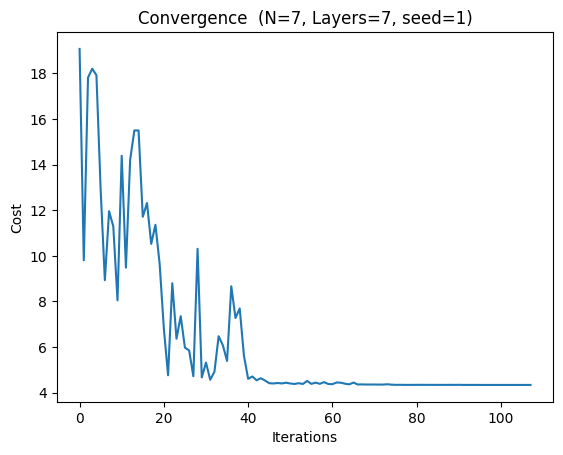

N = 7, capas = 7
  optimal ISLR (reference (N-1)/2) .. 3
  optimal codes/sequences ................... 4 de 128
  best sampled cost ............ 3   -> optimal found
  P(optimal) random sampling ................. 3.125%
  P(optimo) with QAOA ................ 46.600%
  AMPLIFICATION ..................... 14.9x   (signal detected)
  final CVaR (cost trace) ................ 4.34
  iterations ....................... 108
  execution time ............................ 34 s


,solution,probability,cost
0,"{'x': [1, 1, 1, 0, 0, 1, 0]}",0.1195,3
1,"{'x': [0, 1, 0, 0, 1, 1, 1]}",0.1190,3
2,"{'x': [0, 0, 0, 1, 1, 0, 1]}",0.1139,3
3,"{'x': [1, 0, 1, 1, 0, 0, 0]}",0.1136,3
4,"{'x': [1, 1, 1, 0, 1, 0, 0]}",0.0249,7
5,"{'x': [0, 1, 1, 1, 1, 0, 1]}",0.0229,7
6,"{'x': [1, 1, 0, 1, 0, 0, 0]}",0.0228,7



===== Run seed=2 =====


/usr/local/lib/python3.13/dist-packages/classiq/applications/combinatorial_optimization/combinatorial_problem.py:258: ClassiqDeprecationWarning: ExecutionSession.minimize is deprecated; use variational_minimize instead.
  result = _es.minimize(


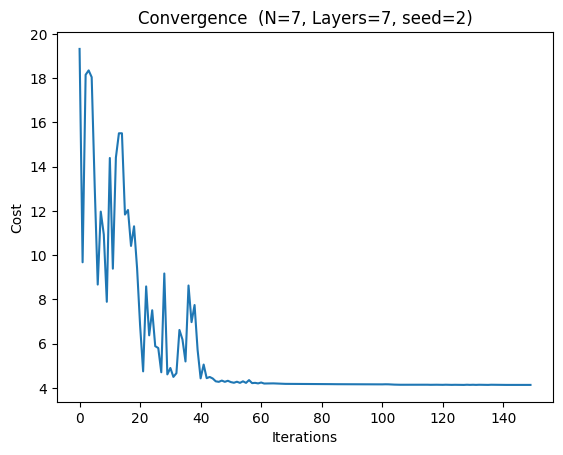

N = 7, capas = 7
  optimal ISLR (reference (N-1)/2) .. 3
  optimal codes/sequences ................... 4 de 128
  best sampled cost ............ 3   -> optimal found
  P(optimal) random sampling ................. 3.125%
  P(optimo) with QAOA ................ 50.200%
  AMPLIFICATION ..................... 16.1x   (signal detected)
  final CVaR (cost trace) ................ 4.13
  iterations ....................... 150
  execution time ............................ 38 s


,solution,probability,cost
0,"{'x': [1, 1, 1, 0, 0, 1, 0]}",0.1288,3
1,"{'x': [0, 1, 0, 0, 1, 1, 1]}",0.1266,3
2,"{'x': [0, 0, 0, 1, 1, 0, 1]}",0.1253,3
3,"{'x': [1, 0, 1, 1, 0, 0, 0]}",0.1213,3
4,"{'x': [1, 0, 1, 1, 1, 1, 0]}",0.0216,7
5,"{'x': [1, 1, 1, 0, 1, 0, 0]}",0.0214,7
6,"{'x': [1, 1, 0, 1, 0, 0, 0]}",0.0207,7



===== Run seed=3 =====


/usr/local/lib/python3.13/dist-packages/classiq/applications/combinatorial_optimization/combinatorial_problem.py:258: ClassiqDeprecationWarning: ExecutionSession.minimize is deprecated; use variational_minimize instead.
  result = _es.minimize(


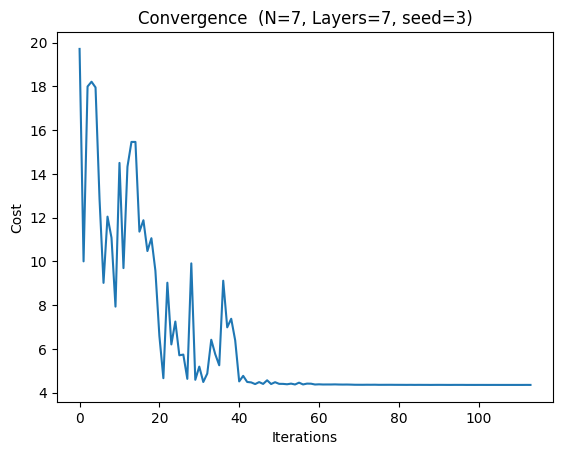

N = 7, capas = 7
  optimal ISLR (reference (N-1)/2) .. 3
  optimal codes/sequences ................... 4 de 128
  best sampled cost ............ 3   -> optimal found
  P(optimal) random sampling ................. 3.125%
  P(optimo) with QAOA ................ 46.520%
  AMPLIFICATION ..................... 14.9x   (signal detected)
  final CVaR (cost trace) ................ 4.35
  iterations ....................... 114
  execution time ............................ 28 s


,solution,probability,cost
0,"{'x': [1, 0, 1, 1, 0, 0, 0]}",0.1172,3
1,"{'x': [1, 1, 1, 0, 0, 1, 0]}",0.1169,3
2,"{'x': [0, 0, 0, 1, 1, 0, 1]}",0.1156,3
3,"{'x': [0, 1, 0, 0, 1, 1, 1]}",0.1155,3
4,"{'x': [1, 0, 0, 0, 0, 1, 0]}",0.0237,7
5,"{'x': [1, 1, 1, 0, 1, 0, 0]}",0.0230,7
6,"{'x': [0, 0, 0, 1, 0, 1, 1]}",0.0225,7



--- Summary of 3 runs (N = 7, layers = 7) ---
  success rate (finds optimal) ... 3/3
  P(optimal) median / best ........ 46.600% / 50.200%
  amplification median / best ..... 14.9x / 16.1x
  dispersion (min-max amplif.) ...... 14.9x - 16.1x
  median execution time .................... 34 s


In [4]:
# =====================================================================
#  QAOA for Waveform Design (ISLR) -- Classiq
#  Multi-start with Plots and Tables
# =====================================================================

import time
import pyomo.environ as pyo
import matplotlib.pyplot as plt
from classiq import *
from classiq.applications.combinatorial_optimization import CombinatorialProblem
from classiq import ExecutionPreferences, ClassiqBackendPreferences

from metricas2_qaoa import metricas, resumen    # el modulo de metricas


# ---------------------------------------------------------------------
# 1. Pyomo model
# ---------------------------------------------------------------------
def islr_model(N):
    m = pyo.ConcreteModel()
    m.I = pyo.RangeSet(0, N - 1)                  # chip indices: 0..N-1
    m.x = pyo.Var(m.I, domain=pyo.Binary)         # 1 bit per chip (Q = 2)

    def s(i):                                     # bit -> spin: 0 -> +1, 1 -> -1
        return 1 - 2 * m.x[i]

    def rho(k):                                   # autocorrelation at lag k
        return sum(s(i) * s(i + k) for i in range(N - k))

    m.obj = pyo.Objective(
        expr=sum(rho(k) ** 2 for k in range(1, N)),   # ISLR, lag 0 excluded
        sense=pyo.minimize)
    return m


# ---------------------------------------------------------------------
# 2. Single execution run
# ---------------------------------------------------------------------
def corrida(N, capas, seed, num_shots=10000, maxiter=150, quantile=0.7,
            graficar=False):
    """Synthesizes, optimizes, samples, and returns (metrics, results_table)."""
    prefs = ExecutionPreferences(
        num_shots=num_shots,
        random_seed=seed,                          # varies between runs
        backend_preferences=ClassiqBackendPreferences(backend_name="simulator"),
    )

    model = islr_model(N)
    combi = CombinatorialProblem(pyo_model=model, num_layers=capas)

    t0 = time.time()
    params = combi.optimize(prefs, maxiter=maxiter, quantile=quantile)
    segundos = time.time() - t0

    result = combi.sample(params)

    if graficar:
        plt.plot(combi.cost_trace)
        plt.xlabel("Iterations"); plt.ylabel("Cost")
        plt.title(f"Convergence  (N={N}, Layers={capas}, seed={seed})")
        plt.show()

    m = metricas(result, N, cost_trace=combi.cost_trace,
                 segundos=segundos, capas=capas)
    return m, result


# ---------------------------------------------------------------------
# 3. Multi-start: multiple seeds, same configuration
# ---------------------------------------------------------------------
def multi_arranque(N, capas, semillas=(1, 2, 3), mostrar_tabla=True,
                   filas=7, **kw):
    """QAOA is variational: each run settles into a different local minimum.
    Median and best-case results are reported, as with any heuristic."""
    salidas, tablas = [], []
    for s in semillas:
        print(f"\n===== Run seed={s} =====")
        m, result = corrida(N, capas, seed=s, **kw)      # <-- results table is stored
        salidas.append(m)
        tablas.append(result)
        if mostrar_tabla:
            tabla = result.sort_values(by="cost").head(filas)
            try:
                display(tabla)            # Colab / Jupyter
            except NameError:
                print(tabla)              # console
    return resumen(salidas), salidas, tablas


# ---------------------------------------------------------------------
# 4. Ejecution
# ---------------------------------------------------------------------
if __name__ == "__main__":
    # Single run example:
    # m, result = run(N=7, layers=7, seed=1, plot=True)

    # Multi-start run (for dossier/reporting):
    res, detalle, tablas = multi_arranque(
        N=7, capas=7, semillas=(1, 2, 3), graficar=True)

In [ ]:
# =====================================================================
#  QAOA for Waveform Design (ISLR) -- Classiq
#  Multi-start with Plots and Tables
# =====================================================================

import time
import pyomo.environ as pyo
import matplotlib.pyplot as plt
from classiq import *
from classiq.applications.combinatorial_optimization import CombinatorialProblem
from classiq import ExecutionPreferences, ClassiqBackendPreferences

from metricas2_qaoa import metricas, resumen    # el modulo de metricas


# ---------------------------------------------------------------------
# 1. Pyomo model
# ---------------------------------------------------------------------
def islr_model(N):
    m = pyo.ConcreteModel()
    m.I = pyo.RangeSet(0, N - 1)                  # chip indices: 0..N-1
    m.x = pyo.Var(m.I, domain=pyo.Binary)         # 1 bit per chip (Q = 2)

    def s(i):                                     # bit -> spin: 0 -> +1, 1 -> -1
        return 1 - 2 * m.x[i]

    def rho(k):                                   # autocorrelation at lag k
        return sum(s(i) * s(i + k) for i in range(N - k))

    m.obj = pyo.Objective(
        expr=sum(rho(k) ** 2 for k in range(1, N)),   # ISLR, lag 0 excluded
        sense=pyo.minimize)
    return m


# ---------------------------------------------------------------------
# 2. Single execution run
# ---------------------------------------------------------------------
def corrida(N, capas, seed, num_shots=10000, maxiter=150, quantile=0.7,
            graficar=False):
    """Synthesizes, optimizes, samples, and returns (metrics, results_table)."""
    prefs = ExecutionPreferences(
        num_shots=num_shots,
        random_seed=seed,                          # varies between runs
        backend_preferences=ClassiqBackendPreferences(backend_name="simulator"),
    )

    model = islr_model(N)
    combi = CombinatorialProblem(pyo_model=model, num_layers=capas)

    t0 = time.time()
    params = combi.optimize(prefs, maxiter=maxiter, quantile=quantile)
    segundos = time.time() - t0

    result = combi.sample(params)

    if graficar:
        plt.plot(combi.cost_trace)
        plt.xlabel("Iterations"); plt.ylabel("Cost")
        plt.title(f"Convergence  (N={N}, Layers={capas}, seed={seed})")
        plt.show()

    m = metricas(result, N, cost_trace=combi.cost_trace,
                 segundos=segundos, capas=capas)
    return m, result


# ---------------------------------------------------------------------
# 3. Multi-start: multiple seeds, same configuration
# ---------------------------------------------------------------------
def multi_arranque(N, capas, semillas=(1, 2, 3), mostrar_tabla=True,
                   filas=7, **kw):
    """QAOA is variational: each run settles into a different local minimum.
    Median and best-case results are reported, as with any heuristic."""
    salidas, tablas = [], []
    for s in semillas:
        print(f"\n===== Run seed={s} =====")
        m, result = corrida(N, capas, seed=s, **kw)      # <-- results table is stored
        salidas.append(m)
        tablas.append(result)
        if mostrar_tabla:
            tabla = result.sort_values(by="cost").head(filas)
            try:
                display(tabla)            # Colab / Jupyter
            except NameError:
                print(tabla)              # console
    return resumen(salidas), salidas, tablas


# ---------------------------------------------------------------------
# 4. Ejecution
# ---------------------------------------------------------------------
if __name__ == "__main__":
    todo = {}
    for N in (5, 7, 11):
        for capas in (3, 7):
            print("\n" + "="*60)
            print(f"  CONFIGURACION  N={N}, capas={capas}")
            print("="*60)
            res, detalle, tablas = multi_arranque(
                N=N, capas=capas, semillas=(1, 2, 3), graficar=False)
            todo[(N, capas)] = res

    print("\n===== FINAL TABLE =====")
    print(f"{'N':>3} {'layers':>6} {'P(opt) median':>15} {'amplification':>15} {'success':>8}")
    for (N, capas), r in todo.items():
        print(f"{N:>3} {capas:>6} {r['p_median']:>14.2%} "
              f"{r['amp_median']:>14.1f}x {r['successes']}/{r['runs']:<4}")


  CONFIGURACION  N=5, capas=3

===== Run seed=1 =====


/usr/local/lib/python3.13/dist-packages/classiq/applications/combinatorial_optimization/combinatorial_problem.py:258: ClassiqDeprecationWarning: ExecutionSession.minimize is deprecated; use variational_minimize instead.
  result = _es.minimize(


N = 5, capas = 3
  optimal ISLR (reference (N-1)/2) .. 2
  optimal codes/sequences ................... 4 de 32
  best sampled cost ............ 2   -> optimal found
  P(optimal) random sampling ................. 12.500%
  P(optimo) with QAOA ................ 74.990%
  AMPLIFICATION ..................... 6.0x   (signal detected)
  final CVaR (cost trace) ................ 2.00
  iterations ....................... 35
  execution time ............................ 13 s


,solution,probability,cost
0,"{'x': [0, 0, 0, 1, 0]}",0.1911,2
1,"{'x': [1, 0, 1, 1, 1]}",0.1895,2
2,"{'x': [1, 1, 1, 0, 1]}",0.1855,2
3,"{'x': [0, 1, 0, 0, 0]}",0.1838,2
15,"{'x': [1, 0, 0, 0, 0]}",0.0070,6
13,"{'x': [0, 1, 0, 1, 1]}",0.0073,6
14,"{'x': [1, 1, 0, 1, 0]}",0.0072,6



===== Run seed=2 =====


...


===== Run seed=3 =====


/usr/local/lib/python3.13/dist-packages/classiq/applications/combinatorial_optimization/combinatorial_problem.py:258: ClassiqDeprecationWarning: ExecutionSession.minimize is deprecated; use variational_minimize instead.
  result = _es.minimize(


N = 11, capas = 7
  optimal ISLR (reference (N-1)/2) .. 5
  optimal codes/sequences ................... 4 de 2048
  best sampled cost ............ 5   -> optimal found
  P(optimal) random sampling ................. 0.195%
  P(optimo) with QAOA ................ 0.680%
  AMPLIFICATION ..................... 3.5x   (signal detected)
  final CVaR (cost trace) ................ 35.51
  iterations ....................... 107
  execution time ............................ 91 s


,solution,probability,cost
64,"{'x': [1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0]}",0.0018,5
142,"{'x': [0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1]}",0.0014,5
144,"{'x': [0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1]}",0.0014,5
34,"{'x': [1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0]}",0.0022,5
512,"{'x': [1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0]}",0.0007,13
133,"{'x': [0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1]}",0.0014,13
735,"{'x': [0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1]}",0.0005,13



--- Summary of 3 runs (N = 11, layers = 7) ---
  success rate (finds optimal) ... 3/3
  P(optimal) median / best ........ 0.260% / 0.680%
  amplification median / best ..... 1.3x / 3.5x
  dispersion (min-max amplif.) ...... 0.9x - 3.5x
  median execution time .................... 92 s

===== FINAL TABLE =====
  N layers   P(opt) median   amplification  success
  5      3         76.42%            6.1x 3/3   
  5      7         73.54%            5.9x 3/3   
  7      3         11.72%            3.8x 3/3   
  7      7         46.60%           14.9x 3/3   
 11      3          0.17%            0.9x 3/3   
 11      7          0.26%            1.3x 3/3   


In [ ]:
res15, det15, tab15 = multi_arranque(N=15, capas=7, semillas=(1, 2))
print(f"\nN=15: amp_median {res15['amp_median']:.1f}x, "
      f"success {res15['successes']}/{res15['runs']}")


===== Run seed=1 =====


/usr/local/lib/python3.13/dist-packages/classiq/applications/combinatorial_optimization/combinatorial_problem.py:258: ClassiqDeprecationWarning: ExecutionSession.minimize is deprecated; use variational_minimize instead.
  result = _es.minimize(


N = 15, capas = 7
  optimal ISLR (reference (N-1)/2) .. 15
  optimal codes/sequences ................... 8 de 32768
  best sampled cost ............ 15   -> optimal found
  P(optimal) random sampling ................. 0.024%
  P(optimo) with QAOA ................ 0.040%
  AMPLIFICATION ..................... 1.6x   (signal detected)
  final CVaR (cost trace) ................ 74.73
  iterations ....................... 112
  execution time ............................ 885 s


,solution,probability,cost
762,"{'x': [0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, ...",0.0002,15
6355,"{'x': [1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, ...",0.0001,15
7374,"{'x': [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, ...",0.0001,15
48,"{'x': [1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, ...",0.0004,23
7512,"{'x': [0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, ...",0.0001,23
5320,"{'x': [1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, ...",0.0001,23
73,"{'x': [0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, ...",0.0004,23



===== Run seed=2 =====


/usr/local/lib/python3.13/dist-packages/classiq/applications/combinatorial_optimization/combinatorial_problem.py:258: ClassiqDeprecationWarning: ExecutionSession.minimize is deprecated; use variational_minimize instead.
  result = _es.minimize(


N = 15, capas = 7
  optimal ISLR (reference (N-1)/2) .. 15
  optimal codes/sequences ................... 8 de 32768
  best sampled cost ............ 15   -> optimal found
  P(optimal) random sampling ................. 0.024%
  P(optimo) with QAOA ................ 0.020%
  AMPLIFICATION ..................... 0.8x   (no improvement over random)
  final CVaR (cost trace) ................ 74.92
  iterations ....................... 105
  execution time ............................ 824 s


,solution,probability,cost
2420,"{'x': [1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, ...",0.0001,15
2661,"{'x': [0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, ...",0.0001,15
1419,"{'x': [1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, ...",0.0002,23
1770,"{'x': [0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, ...",0.0002,23
120,"{'x': [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, ...",0.0003,23
6132,"{'x': [1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, ...",0.0001,23
3354,"{'x': [1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, ...",0.0001,23



--- Summary of 2 runs (N = 15, layers = 7) ---
  success rate (finds optimal) ... 2/2
  P(optimal) median / best ........ 0.030% / 0.040%
  amplification median / best ..... 1.2x / 1.6x
  dispersion (min-max amplif.) ...... 0.8x - 1.6x
  median execution time .................... 855 s

N=15: amp_median 1.2x, success 2/2


Let's get the depth of the circuit measured by Classiq: how many gates there are and what depth the already synthesized circuit has.

In [9]:
# Circuit resources -- synthesis only, no optimization
combi = CombinatorialProblem(pyo_model=islr_model(5), num_layers=3)
qprog = synthesize(combi.get_model())
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/3Jr1QsiREQ9ZCjyrH35elwPesGo


In [10]:
# Circuit resources -- synthesis only, no optimization
combi = CombinatorialProblem(pyo_model=islr_model(7), num_layers=7)
qprog = synthesize(combi.get_model())
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/3Jr1dtWfYFYEsJ1JDlW1uksKF5F


In [11]:
# Circuit resources -- synthesis only, no optimization
combi = CombinatorialProblem(pyo_model=islr_model(11), num_layers=7)
qprog = synthesize(combi.get_model())
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/3Jr1xfTY61u5XRBb04h1yDtZlrN


In [12]:
# Circuit resources -- synthesis only, no optimization
combi = CombinatorialProblem(pyo_model=islr_model(15), num_layers=7)
qprog = synthesize(combi.get_model())
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/3Jr2Ws1IBtL1ErL7ZKpsppk0bMZ


In [13]:
# Circuit resources -- synthesis only, no optimization
combi = CombinatorialProblem(pyo_model=islr_model(20), num_layers=7)
qprog = synthesize(combi.get_model())
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/3Jr2qOndJggYEE4rwc6MCqhZ3Ys
